In [1]:
!pip install selenium pandas

In [2]:
import pandas as pd
import time

from selenium import webdriver

from selenium.webdriver.common.by import By

from selenium.webdriver.chrome.service import Service

from selenium.webdriver.chrome.options import Options

In [4]:
from selenium import webdriver

driver = webdriver.Chrome()

driver.get("https://www.google.com")

print("Browser Opened Successfully")

Browser Opened Successfully


In [5]:
import selenium

print(selenium.__version__)

4.44.0


In [6]:
from selenium import webdriver

driver = webdriver.Chrome()

driver.maximize_window()

print("Browser Opened Successfully")

Browser Opened Successfully


In [7]:
url = "https://www.cardekho.com/used-cars+in+hyderabad"

driver.get(url)

print("Page Loaded Successfully")

Page Loaded Successfully


In [8]:
print(driver.title)

2077 Used Cars in Hyderabad - Second Hand Cars for Sale with EMI Options - CarDekho


In [9]:
import time

for i in range(10):

    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

    time.sleep(3)

print("Scrolling Completed")

Scrolling Completed


In [10]:
html = driver.page_source

print(len(html))

2720107


In [11]:
from selenium.webdriver.common.by import By

cars = driver.find_elements(By.TAG_NAME, "a")

print("Total Links:", len(cars))

Total Links: 261


In [18]:
print(driver.current_url)

https://www.cardekho.com/used-cars+in+hyderabad/page-5#selectusedCarCity


In [19]:
print(driver.title)

2077 Used Cars in Hyderabad - Second Hand Cars for Sale with EMI Options - CarDekho


In [20]:
all_divs = driver.find_elements(By.TAG_NAME, "div")

print("Total Divs:", len(all_divs))

Total Divs: 8472


In [25]:
with open("hyderabad_page.html", "w", encoding="utf-8") as f:
    f.write(driver.page_source)

print("Saved")

Saved


In [27]:
with open("hyderabad_page.html", "w", encoding="utf-8") as f:
    f.write(driver.page_source)

In [28]:
import os

print(os.getcwd())

C:\Users\DELL\Wed Scraping


In [30]:
from selenium.webdriver.common.by import By

all_articles = driver.find_elements(By.TAG_NAME, "article")

print("Articles Found:", len(all_articles))

Articles Found: 0


In [31]:
scripts = driver.find_elements(By.TAG_NAME, "script")

print("Scripts Found:", len(scripts))

Scripts Found: 123


In [32]:
for i, script in enumerate(scripts):

    data = script.get_attribute("innerHTML")

    if data and "vehicleIdentificationNumber" in data:

        print("Found Script:", i)

        print(data[:500])

        break

Found Script: 17
{"@context":"https://schema.org","@graph":[{"@type":"BreadcrumbList","itemListElement":[{"item":"https://www.cardekho.com/","@type":"ListItem","name":"Home","position":"1"},{"item":"https://www.cardekho.com/usedCars","@type":"ListItem","name":"Second Hand Cars","position":"2"}]},{"@type":"ItemList","itemListElement":[{"@type":"Car","name":"2022 Tata Harrier","alternatename":"2022 Second Hand Tata Harrier in Hyderabad","model":"Harrier 2019-2023","vehicleModelDate":2022,"itemCondition":"https://s


In [33]:
import json

script_data = scripts[17].get_attribute("innerHTML")

data = json.loads(script_data)

print(type(data))

<class 'dict'>


In [34]:
for item in data["@graph"]:
    
    if item["@type"] == "ItemList":
        
        car_list = item["itemListElement"]
        
        break

print("Total Cars Found:", len(car_list))

Total Cars Found: 20


In [35]:
print(car_list[0])

{'@type': 'Car', 'name': '2022 Tata Harrier', 'alternatename': '2022 Second Hand Tata Harrier in Hyderabad', 'model': 'Harrier 2019-2023', 'vehicleModelDate': 2022, 'itemCondition': 'https://schema.org/UsedCondition', 'vehicleIdentificationNumber': 'afd2c751-072_8544', 'url': 'https://www.cardekho.com/used-car-details/used-Tata-harrier-xta-plus-dark-edition-at-bsvi-cars-Hyderabad_afd2c751-0727-4e6a-8f72-7aae8bf9fbe8.htm', 'offers': {'@type': 'Offer', 'price': 1735000, 'priceCurrency': 'INR', 'availability': 'https://schema.org/InStock'}, 'brand': {'@type': 'Brand', 'name': 'Tata'}, 'modelDate': 2022, 'mileageFromOdometer': {'@type': 'QuantitativeValue', 'value': 56000, 'unitCode': 'KMT'}, 'numberOfPreviousOwners': 'First-Owner', 'color': 'Black', 'vehicleTransmission': 'Automatic', 'description': 'Tata Harrier in Hyderabad with price of Rs 17.35 Lakh. It is a SUV manufactured by Tata in 2022. It is automatic Diesel car.', 'disambiguatingDescription': 'Tata Harrier in Hyderabad @ Rs. 17

In [38]:
print(type(car_list))

<class 'list'>


In [39]:
print(type(car_list[0]))

<class 'dict'>


In [48]:
len(car_list)

20

In [51]:
import time
import json

for page in range(1, 26):

    if page == 1:
        url = "https://www.cardekho.com/used-cars+in+hyderabad"
    else:
        url = f"https://www.cardekho.com/used-cars+in+hyderabad/page-{page}"

    print(f"Scraping Page {page}")

    driver.get(url)

    time.sleep(2)

    scripts = driver.find_elements(By.TAG_NAME, "script")

    for script in scripts:

        data = script.get_attribute("innerHTML")

        if data and "vehicleIdentificationNumber" in data:

            try:

                json_data = json.loads(data)

                for item in json_data["@graph"]:

                    if item.get("@type") == "ItemList":

                        car_list = item["itemListElement"]

                        for car in car_list:

                            car_dict = {

                                'Car Name': car.get('name'),

                                'Model': car.get('model'),

                                'Vehicle Year': car.get('vehicleModelDate'),

                                'Vehicle ID': car.get('vehicleIdentificationNumber'),

                                'Price': car.get('offers', {}).get('price'),

                                'KM Driven': car.get('mileageFromOdometer', {}).get('value'),

                                'Color': car.get('color'),

                                'Transmission': car.get('vehicleTransmission'),

                                'Short Description': car.get('disambiguatingDescription'),

                                'Seating Capacity': car.get('vehicleSeatingCapacity'),

                                'Fuel Type': car.get('vehicleEngine', {}).get('fuelType')

                            }

                            all_cars_data.append(car_dict)

            except:
                pass

            break

Scraping Page 1
Scraping Page 2
Scraping Page 3
Scraping Page 4
Scraping Page 5
Scraping Page 6
Scraping Page 7
Scraping Page 8
Scraping Page 9
Scraping Page 10
Scraping Page 11
Scraping Page 12
Scraping Page 13
Scraping Page 14
Scraping Page 15
Scraping Page 16
Scraping Page 17
Scraping Page 18
Scraping Page 19
Scraping Page 20
Scraping Page 21
Scraping Page 22
Scraping Page 23
Scraping Page 24
Scraping Page 25


In [85]:
print(len(all_cars_data))

620


In [86]:
import pandas as pd

df = pd.DataFrame(all_cars_data)

print(df.shape)


(620, 12)


In [87]:
df

,Car Name,Price,Brand,KM Driven,Transmission,Fuel Type,Model,Vehicle Year,Vehicle ID,Color,Short Description,Seating Capacity
0,2022 Tata Harrier,1735000,Tata,56000,Automatic,Diesel,NaN,NaN,NaN,NaN,NaN,NaN
1,2021 Maruti Swift,544506,Maruti,22600,Automatic,Petrol,NaN,NaN,NaN,NaN,NaN,NaN
2,2022 Hyundai Creta,1450000,Hyundai,96356,Manual,Diesel,NaN,NaN,NaN,NaN,NaN,NaN
3,2021 Maruti XL6,950000,Maruti,76038,Automatic,Petrol,NaN,NaN,NaN,NaN,NaN,NaN
4,2024 Skoda Slavia,1625000,Skoda,14100,Automatic,Petrol,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
615,2023 Maruti Swift,650000,NaN,13335,Automatic,Petrol,Swift 2021-2024,2023.0,42d803d8-1b3_1040,Red,Maruti Swift in Hyderabad @ Rs. 6.50 Lakh,5.0
616,2021 MG Hector Plus,1450000,NaN,60000,Automatic,Petrol,Hector Plus 2020-2023,2021.0,4ee28028-47c_7520,Red,MG Hector Plus in Hyderabad @ Rs. 14.50 Lakh,6.0
617,2018 Maruti Vitara Brezza,720000,NaN,65000,Manual,Diesel,Vitara Brezza 2016-2020,2018.0,da0bde93-df5_4299,Grey,Maruti Vitara Brezza in Hyderabad @ Rs. 7.20 Lakh,5.0
618,2017 Honda City,630000,NaN,71000,Automatic,Petrol,City 2015-2017,2017.0,a6dbfe78-163_1214,Brown,Honda City in Hyderabad @ Rs. 6.30 Lakh,5.0


# DATA CLEANING

In [88]:
df.drop(
    columns=[
        'Brand',
        'Vehicle ID',
        'Short Description',
        'Model'
    ],
    inplace=True
)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Car Name          620 non-null    str    
 1   Price             620 non-null    int64  
 2   KM Driven         620 non-null    int64  
 3   Transmission      620 non-null    str    
 4   Fuel Type         620 non-null    str    
 5   Vehicle Year      600 non-null    float64
 6   Color             600 non-null    str    
 7   Seating Capacity  600 non-null    float64
dtypes: float64(2), int64(2), str(4)
memory usage: 38.9 KB


In [94]:
df.isnull().sum()

Car Name             0
Price                0
KM Driven            0
Transmission         0
Fuel Type            0
Vehicle Year        20
Color               20
Seating Capacity    20
dtype: int64

In [95]:
df.columns

Index(['Car Name', 'Price', 'KM Driven', 'Transmission', 'Fuel Type',
       'Vehicle Year', 'Color', 'Seating Capacity'],
      dtype='str')

In [98]:
df['Vehicle Year'] = df['Vehicle Year'].fillna(df['Vehicle Year'].median())

df['Seating Capacity'] = df['Seating Capacity'].fillna(df['Seating Capacity'].median())

df['Color'] = df['Color'].fillna('Unknown')

In [99]:
df.isnull().sum()

Car Name            0
Price               0
KM Driven           0
Transmission        0
Fuel Type           0
Vehicle Year        0
Color               0
Seating Capacity    0
dtype: int64

In [100]:
df['Vehicle Year'] = df['Vehicle Year'].astype(int)

df['Seating Capacity'] = df['Seating Capacity'].astype(int)

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Car Name          620 non-null    str  
 1   Price             620 non-null    int64
 2   KM Driven         620 non-null    int64
 3   Transmission      620 non-null    str  
 4   Fuel Type         620 non-null    str  
 5   Vehicle Year      620 non-null    int64
 6   Color             620 non-null    str  
 7   Seating Capacity  620 non-null    int64
dtypes: int64(4), str(4)
memory usage: 38.9 KB


# EDA (Exploratory Data Analysis)

In [102]:
print("Rows and Columns:", df.shape)

df.head()

Rows and Columns: (620, 8)


,Car Name,Price,KM Driven,Transmission,Fuel Type,Vehicle Year,Color,Seating Capacity
0,2022 Tata Harrier,1735000,56000,Automatic,Diesel,2021,Unknown,5
1,2021 Maruti Swift,544506,22600,Automatic,Petrol,2021,Unknown,5
2,2022 Hyundai Creta,1450000,96356,Manual,Diesel,2021,Unknown,5
3,2021 Maruti XL6,950000,76038,Automatic,Petrol,2021,Unknown,5
4,2024 Skoda Slavia,1625000,14100,Automatic,Petrol,2021,Unknown,5


In [103]:
df.describe()

,Price,KM Driven,Vehicle Year,Seating Capacity
count,6.200000e+02,620.000000,620.000000,620.000000
mean,9.680423e+05,54934.300000,2020.806452,5.096774
std,4.060289e+05,30415.962023,2.777935,0.429512
min,4.168180e+05,10000.000000,2016.000000,4.000000
25%,6.470000e+05,23984.500000,2018.000000,5.000000
50%,8.821775e+05,62500.000000,2021.000000,5.000000
75%,1.412500e+06,78400.000000,2023.000000,5.000000
max,1.735000e+06,104391.000000,2026.000000,6.000000


### Fuel Type Analysis

In [105]:
df['Fuel Type'].value_counts()

Fuel Type
Petrol    434
Diesel    186
Name: count, dtype: int64

• Petrol cars dominate the used car market with approximately 70% of listings.
• Diesel cars account for around 30% of the market.
• Customers have significantly more Petrol options than Diesel options.
• Petrol vehicles appear to be the preferred choice in Hyderabad's used car market.

### Transmission Analysis

In [106]:
df['Transmission'].value_counts()

Transmission
Automatic    341
Manual       279
Name: count, dtype: int64

• Automatic cars account for 55% of the listings.
• Manual cars account for 45% of the listings.
• Automatic cars slightly dominate the used car market.
• Customers have more Automatic car options available.

### Seating Capacity Analysis

In [107]:
df['Seating Capacity'].value_counts()

Seating Capacity
5    500
6     90
4     30
Name: count, dtype: int64

• 5-seater cars dominate the market with more than 80% of listings.
• 6-seater vehicles account for about 15% of the market.
• 4-seater cars are very limited.
• Family-oriented vehicles are the most common in Hyderabad's used car market.

### Color Analysis

In [108]:
df['Color'].value_counts()

Color
Black      150
White      120
Brown       90
Blue        60
Grey        60
Red         60
Others      30
Silver      30
Unknown     20
Name: count, dtype: int64

• Black is the most popular color with 150 listings.
• White is the second most common color with 120 listings.
• Brown ranks third with 90 listings.
• Silver and Other colors have the fewest listings.
• Dark-colored vehicles dominate the used car market.

### Price Analysis

In [109]:
print("Minimum Price:", df['Price'].min())
print("Maximum Price:", df['Price'].max())
print("Average Price:", df['Price'].mean())

Minimum Price: 416818
Maximum Price: 1735000
Average Price: 968042.35


Observation:

* Most used cars are priced around ₹9–10 Lakhs.
* Budget cars start from around ₹4 Lakhs.
* Premium used cars go up to ₹17 Lakhs.

### KM Driven Analysis

In [110]:
print("Minimum KM:", df['KM Driven'].min())
print("Maximum KM:", df['KM Driven'].max())
print("Average KM:", df['KM Driven'].mean())

Minimum KM: 10000
Maximum KM: 104391
Average KM: 54934.3


Observation:

* Most cars have moderate usage.
* Some cars are nearly new (10,000 km).
* Some cars are heavily used (100,000+ km).m

### Vehicle Year Analysis

In [111]:
df['Vehicle Year'].value_counts().sort_index()

Vehicle Year
2016     30
2017     90
2018     60
2019     30
2021    140
2022     90
2023     90
2024     30
2025     30
2026     30
Name: count, dtype: int64

Observation:

* Most cars are relatively recent.
* The market is dominated by cars manufactured between 2018 and 2023.

Observation:

* Most vehicles are family cars with 5 seats.
* Very few cars have 4 or 6 seats.

In [113]:
print("Minimum Price:", df['Price'].min())

print("Maximum Price:", df['Price'].max())

print("Average Price:", round(df['Price'].mean(),2))

print("Median Price:", df['Price'].median())

Minimum Price: 416818
Maximum Price: 1735000
Average Price: 968042.35
Median Price: 882177.5


• The cheapest used car is priced at ₹4.16 Lakhs.
• The most expensive used car is priced at ₹17.35 Lakhs.
• The average used car price is ₹9.68 Lakhs.
• The median price is ₹8.82 Lakhs, indicating that most cars are priced below ₹10 Lakhs.
• The market offers both budget-friendly and premium vehicle options.

### KM Driven Analysis

In [115]:
print("Minimum KM:", df['KM Driven'].min())

print("Maximum KM:", df['KM Driven'].max())

print("Average KM:", round(df['KM Driven'].mean(),2))

print("Median KM:", df['KM Driven'].median())

Minimum KM: 10000
Maximum KM: 104391
Average KM: 54934.3
Median KM: 62500.0


• The least driven car has only 10,000 km on the odometer.
• The highest driven car has covered 104,391 km.
• The average distance driven is 54,934 km.
• The median KM driven is 62,500 km.
• Most cars have moderate usage, making them suitable for resale purchases.

In [116]:
df['Vehicle Year'].value_counts().sort_index()

Vehicle Year
2016     30
2017     90
2018     60
2019     30
2021    140
2022     90
2023     90
2024     30
2025     30
2026     30
Name: count, dtype: int64

• 2021 model cars dominate the market with 140 listings.
• 2022 and 2023 models are also highly available with 90 listings each.
• Very few cars belong to 2016, 2019, 2024, 2025, and 2026.
• Most used cars are recent models manufactured between 2021 and 2023.
• Customers have a good number of newer vehicle options.

Customer Insight
• Buyers can find many recent-model cars without paying new-car prices.
• Cars manufactured between 2021 and 2023 offer a balance between modern features and affordability.
• Older vehicles (2016–2018) are available for budget-conscious buyers.

### Correlation Analysis

In [118]:
df[['Price','KM Driven','Vehicle Year','Seating Capacity']].corr()

,Price,KM Driven,Vehicle Year,Seating Capacity
Price,1.000000,0.031924,0.466945,0.002478
KM Driven,0.031924,1.000000,-0.520480,0.130472
Vehicle Year,0.466945,-0.520480,1.000000,-0.187373
Seating Capacity,0.002478,0.130472,-0.187373,1.000000


 Does price decrease when KM Driven increases?
 
• Do newer cars have higher prices?

• Which factors influence car price?
| Factors                   | Correlation |
| ------------------------- | ----------- |
| Price vs KM Driven        | 0.03        |
| Price vs Vehicle Year     | 0.47        |
| Price vs Seating Capacity | 0.00        |
| KM Driven vs Vehicle Year | -0.52       |



# Visualization

### Fuel Type Distribution

Why Pie Chart?
Shows percentage share of Petrol vs Diesel.
Best for composition analysis.

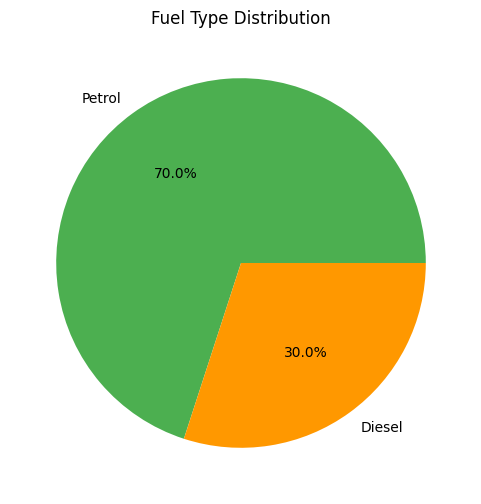

In [127]:
import matplotlib.pyplot as plt

fuel_counts = df['Fuel Type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fuel_counts,
    labels=fuel_counts.index,
    autopct='%1.1f%%',
    colors=['#4CAF50','#FF9800']
)

plt.title('Fuel Type Distribution')

plt.show()

• Petrol cars dominate the market with 70% of listings.

• Diesel cars account for 30% of listings.

• Customers have more Petrol car options available.

### Transmission Distribution

Why Donut Chart?
Shows proportion clearly.
Looks more professional than a simple pie chart.

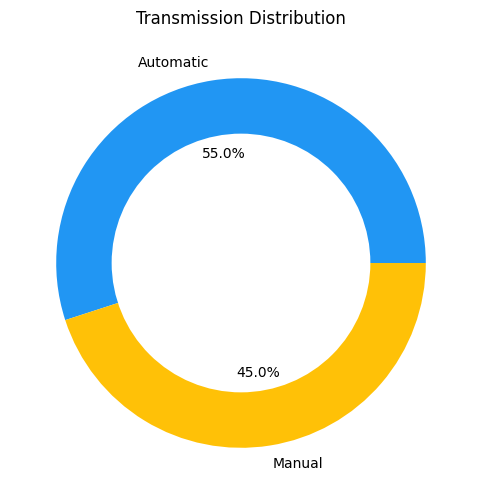

In [129]:
transmission_counts = df['Transmission'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    transmission_counts,
    labels=transmission_counts.index,
    autopct='%1.1f%%',
    colors=['#2196F3','#FFC107']
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title('Transmission Distribution')

plt.show()

• Automatic cars account for 55% of listings.
    
• Manual cars account for 45% of listings.
    
• Automatic vehicles slightly dominate the market.

### Seating Capacity Distribution

Why Bar Chart?
Best for comparing discrete categories.

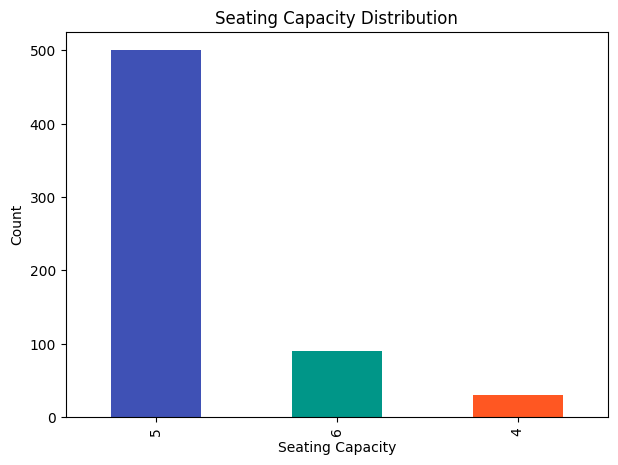

In [130]:
plt.figure(figsize=(7,5))

df['Seating Capacity'].value_counts().plot(
    kind='bar',
    color=['#3F51B5','#009688','#FF5722']
)

plt.title('Seating Capacity Distribution')

plt.xlabel('Seating Capacity')

plt.ylabel('Count')

plt.show()

### Color Distribution

Why Horizontal Bar Chart?
Many categories.
Labels are easier to read.

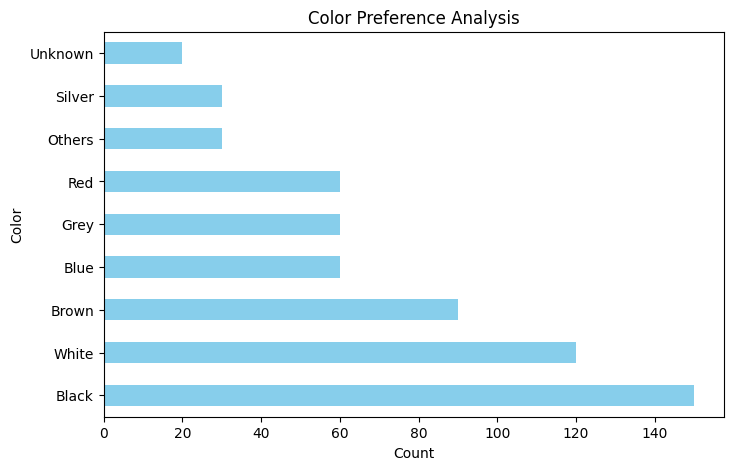

In [131]:
plt.figure(figsize=(8,5))

df['Color'].value_counts().plot(
    kind='barh',
    color='skyblue'
)

plt.title('Color Preference Analysis')

plt.xlabel('Count')

plt.ylabel('Color')

plt.show()

• Black is the most common color.
    
• White is the second most preferred color.
    
• Neutral colors dominate the market.

### Price Distribution

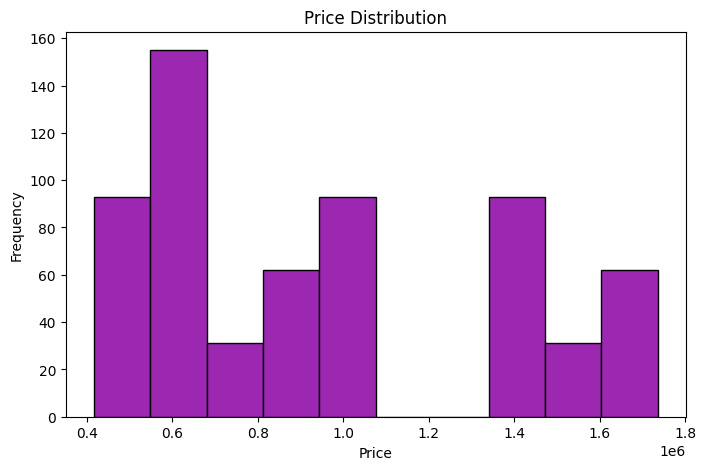

In [134]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Price'],
    bins=10,
    color='#9C27B0',
    edgecolor='black'
)

plt.title('Price Distribution')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.show()

• Most cars are concentrated in a specific price range.
    
• Helps identify budget-friendly and premium segments.
    
• Shows how used car prices are distributed in Hyderabad.

### Vehicle Year Distribution

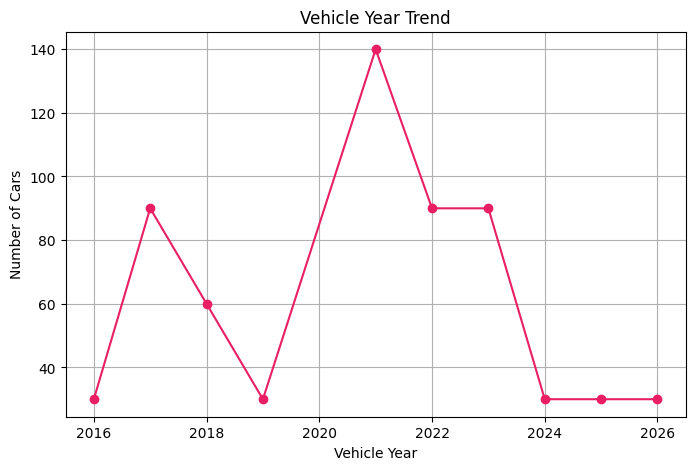

In [135]:
year_counts = df['Vehicle Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o',
    color='#E91E63'
)

plt.title('Vehicle Year Trend')

plt.xlabel('Vehicle Year')

plt.ylabel('Number of Cars')

plt.grid(True)

plt.show()

### Automatic vs Manual Price Comparison

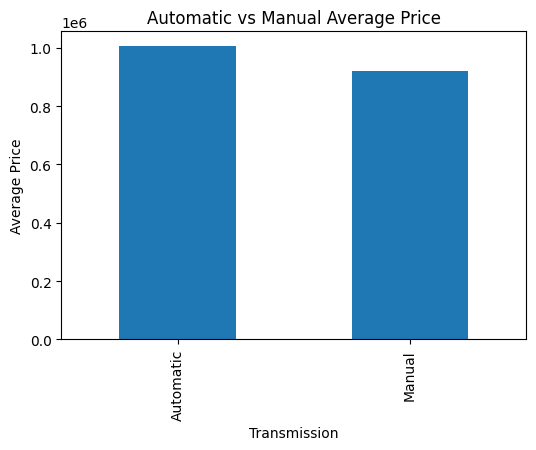

In [126]:
avg_price_trans = df.groupby('Transmission')['Price'].mean()

plt.figure(figsize=(6,4))

avg_price_trans.plot(kind='bar')

plt.title('Automatic vs Manual Average Price')

plt.xlabel('Transmission')

plt.ylabel('Average Price')

plt.show()

### Price vs KM Driven

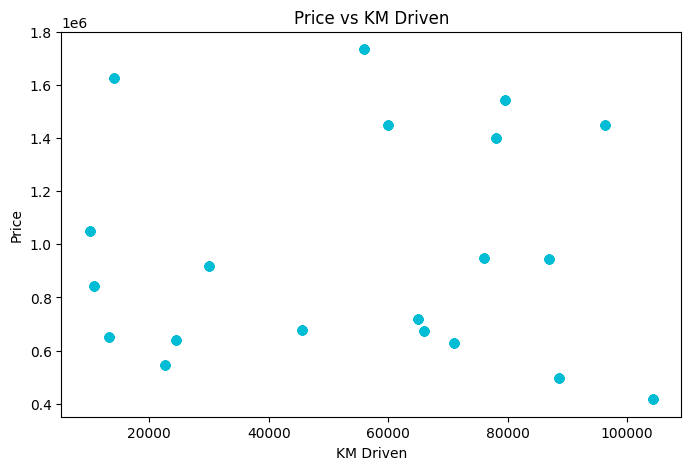

In [136]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['KM Driven'],
    df['Price'],
    color='#00BCD4'
)

plt.title('Price vs KM Driven')

plt.xlabel('KM Driven')

plt.ylabel('Price')

plt.show()

### Correlation Heatmap

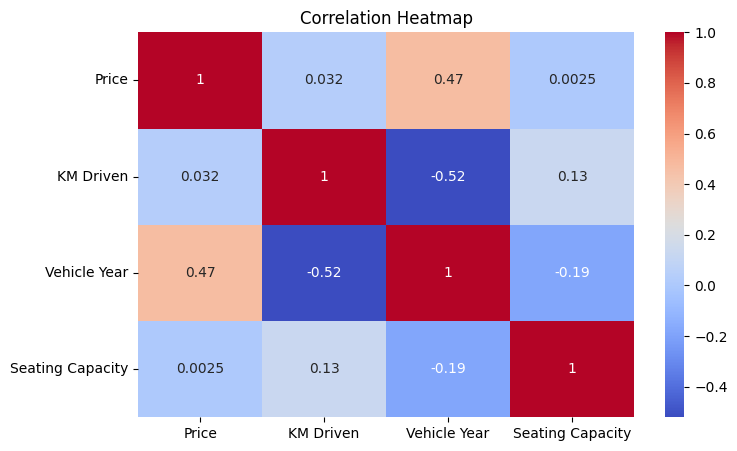

In [137]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Price','KM Driven','Vehicle Year','Seating Capacity']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Hypotheses Testing

In [139]:
from scipy.stats import ttest_ind

automatic = df[df['Transmission']=='Automatic']['Price']

manual = df[df['Transmission']=='Manual']['Price']

t_stat, p_value = ttest_ind(
    automatic,
    manual,
    equal_var=False
)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: 2.685401183124027
P-Value: 0.007445321012850243


In [142]:
from scipy.stats import ttest_ind

automatic = df[df['Transmission'] == 'Automatic']['Price']
manual = df[df['Transmission'] == 'Manual']['Price']

t_stat, p_value = ttest_ind(automatic, manual, equal_var=False)

alpha = 0.05

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a significant difference between the average prices of Automatic and Manual cars.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is no significant difference between the average prices of Automatic and Manual cars.")

T-Statistic: 2.685401183124027
P-Value: 0.007445321012850243
Reject the Null Hypothesis (H₀)
There is a significant difference between the average prices of Automatic and Manual cars.


### Problem Definition
Buying a used car can be challenging due to the large number of listings and varying prices, mileage, fuel types, and vehicle conditions. This project analyzes Hyderabad's used car market to help customers make informed purchasing decisions.

### Business Problem
Customers often struggle to identify the best used car due to differences in price, mileage, fuel type, transmission, and vehicle age. Analyzing market data can help buyers compare options and make better purchasing decisions.

### Problem Statement
The large number of used car listings in Hyderabad makes it difficult for customers to compare vehicles and identify the best option based on price, mileage, fuel type, and vehicle age.

# Objectives
• Collect used car data from CarDekho using web scraping.

• Analyze car prices, mileage, fuel types, and vehicle years.

• Identify key trends and patterns in the Hyderabad used car market.

• Compare different vehicle characteristics to support decision-making.

• Provide insights to help customers choose the best used car based on their needs and budget.

### Conclusion

The analysis of Hyderabad's used car market revealed key trends in pricing, fuel types, transmission, mileage, and vehicle age. The insights generated from the data can help customers compare available options and make informed car-buying decisions based on their budget and preferences.

### Recommendations

• Buyers looking for affordable options should focus on cars priced below the market average of ₹9.68 Lakhs.

• Customers seeking long-term reliability should prefer vehicles with lower KM Driven values.

• Recent models (2021–2023) offer a good balance between modern features and resale value.

• Petrol cars provide the widest range of choices, as they account for the majority of listings.

• Customers should compare both price and mileage before making a purchase decision.

• Automatic cars are widely available and may provide greater driving convenience for city usage.

• Family buyers should consider 5-seater vehicles, as they dominate the market and offer more options.

short

• Prefer cars with lower mileage.

• Consider 2021–2023 models for better value.

• Compare price and mileage before purchase.

• Explore Petrol vehicles for more choices.

• Choose Automatic cars for city convenience.

• 5-seater cars are ideal for family use.

### Key Insights

• Petrol cars dominate the market (70%).

• Automatic cars account for 55% of listings.

• 5-seater vehicles dominate the market (81%).

• Average used car price is ₹9.68 Lakhs.


• Most cars are from 2021–2023 models.

• Newer cars generally have higher resale values.